# Projeto Integrador III – Análise de dados
## Predição de Inadimplência com Base no Perfil de Clientes de Cartão de Crédito

### Integrantes
- Hellen Karla Costa Campos Moraes de Melo 
- José Henrique Bessi Wolkers
- Kaio Soares Pacheco  
- Yasmim Luiz dos Santos  

### Descrição do Projeto

Este projeto tem como objetivo analisar dados de clientes de cartão de crédito para identificar padrões associados à inadimplência e desenvolver modelos capazes de prever o risco de não pagamento.

A análise será realizada utilizando técnicas de estatística e aprendizado de máquina, incluindo análise exploratória de dados, testes de hipóteses e modelos de classificação.

### Problema de Pesquisa

Quais características dos clientes estão mais associadas à inadimplência e é possível prever, com base nesses dados, quais clientes apresentam maior risco de não pagamento?

### Objetivo deste Notebook

Este notebook corresponde à fase de desenvolvimento e análise inicial do projeto, incluindo:

- tratamento e preparação dos dados  
- análise exploratória (EDA)  
- aplicação de testes estatísticos  
- desenvolvimento inicial de modelos de machine learning  

## Glossário das colunas do dataset 'Default of Credit Card Clients Dataset'
O dataset utilizado contém variáveis relacionadas ao perfil demográfico, histórico de pagamento e comportamento financeiro dos clientes, conforme descrito a seguir:

### ID:
Identificador único de cada cliente.

### LIMIT_BAL:
Valor do limite de crédito concedido ao cliente (em dólares taiwaneses – NT$), incluindo crédito individual e familiar/suplementar.

### SEX:
Sexo do cliente:

- 1 = masculino
- 2 = feminino

### EDUCATION:
Nível de escolaridade do cliente:
- 1 = pós-graduação
- 2 = ensino superior (graduação)
- 3 = ensino médio
- 4 = outros
- 5 = desconhecido
- 6 = desconhecido

### MARRIAGE:
Estado civil do cliente:
- 1 = casado
- 2 = solteiro
- 3 = outros

### AGE:
Idade do cliente (em anos).

### Histórico de Pagamento (PAY_X)

Representam o status de pagamento mensal do cliente:

- **PAY_0:** status de pagamento em setembro de 2005
- **PAY_2:** status de pagamento em agosto de 2005
- **PAY_3:** status de pagamento em julho de 2005
- **PAY_4:** status de pagamento em junho de 2005
- **PAY_5:** status de pagamento em maio de 2005
- **PAY_6:** status de pagamento em abril de 2005

Escala de valores:
- 1 = pagamento em dia
- 1 = atraso de 1 mês
- 2 = atraso de 2 meses
...
- 8 = atraso de 8 meses
- 9 = atraso de 9 meses ou mais

### Valores de Fatura (BILL_AMT_X)
Representam o valor da fatura do cartão em cada mês (em NT$):
- BILL_AMT1: setembro de 2005
- BILL_AMT2: agosto de 2005
- BILL_AMT3: julho de 2005
- BILL_AMT4: junho de 2005
- BILL_AMT5: maio de 2005
- BILL_AMT6: abril de 2005

### Valores de Pagamento (PAY_AMT_X)
Representam o valor pago pelo cliente em cada mês (em NT$):
- PAY_AMT1: pagamento em setembro de 2005
- PAY_AMT2: pagamento em agosto de 2005
- PAY_AMT3: pagamento em julho de 2005
- PAY_AMT4: pagamento em junho de 2005
- PAY_AMT5: pagamento em maio de 2005
- PAY_AMT6: pagamento em abril de 2005

### **Variável Alvo**

**default.payment.next.month:**
Indica se o cliente foi inadimplente no mês seguinte:

- 1 = sim (inadimplente)
- 0 = não (adimplente)

### Dataset Utilizado
Default of Credit Card Clients Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv('UCI_Credit_Card.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### Estrutura dos dados

In [3]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [5]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### Tratamento de Dados

Inicialmente, foi realizada a verificação de valores nulos no dataset para garantir a qualidade dos dados antes das análises.

In [6]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

Não foram identificados valores nulos na base.


In [7]:
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [8]:
df['EDUCATION'] = df['EDUCATION'].replace([0,5,6],4)

In [9]:
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

In [10]:
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)
df['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64

Também foram verificadas inconsistências em variáveis categóricas, como EDUCATION e MARRIAGE.

### Criação de novas variáveis

In [11]:
df['divida_total'] = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3',
                         'BILL_AMT4','BILL_AMT5','BILL_AMT6']].sum(axis=1)

df['pagamento_total'] = df[['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                            'PAY_AMT4','PAY_AMT5','PAY_AMT6']].sum(axis=1)

### Distribuição da variável alvo

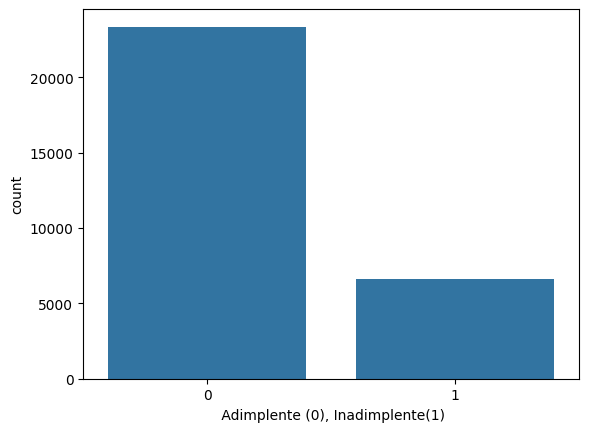

In [12]:
sns.countplot(x='default.payment.next.month',data=df)
plt.xlabel(" Adimplente (0), Inadimplente(1)")
plt.show()

O gráfico indica que há uma distribuição de adimplentes maior do que de inadimplentes

### Comparação do limite de crédito entre adimplentes e inadimplentes

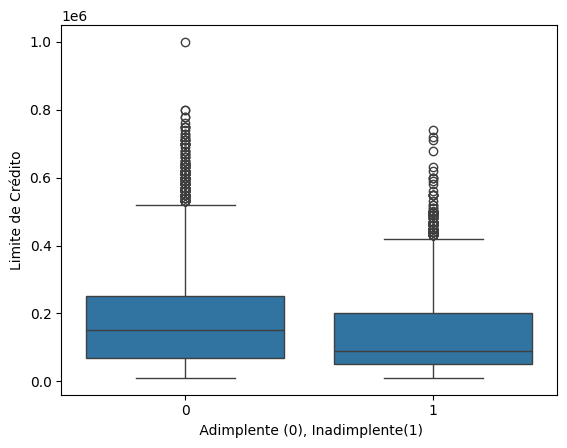

In [13]:
sns.boxplot(x='default.payment.next.month', y='LIMIT_BAL', data=df)
plt.xlabel(" Adimplente (0), Inadimplente(1)")
plt.ylabel("Limite de Crédito")
plt.show()

Pode se observar que clientes inadimplentes tendem a apresentar limites de créditos menores em comparação aos adimplentes, sugerindo que o limite de crédito pode estar relacionado ao risco de inadimplência.

### Relação entre idade e Inadimplência

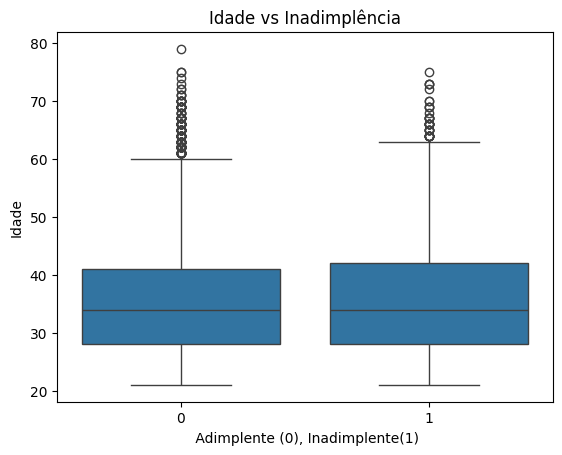

In [14]:
sns.boxplot(x='default.payment.next.month', y='AGE', data=df)
plt.title("Idade vs Inadimplência")
plt.xlabel(" Adimplente (0), Inadimplente(1)")
plt.ylabel("Idade")
plt.show()

A distribuição de idade entre os grupos não apresenta uma diferença muito grande, indicando que a idade pode não ser um fator determinante isolado para inadimplência.

### Relação entre histórico de pagamento e inadimplência

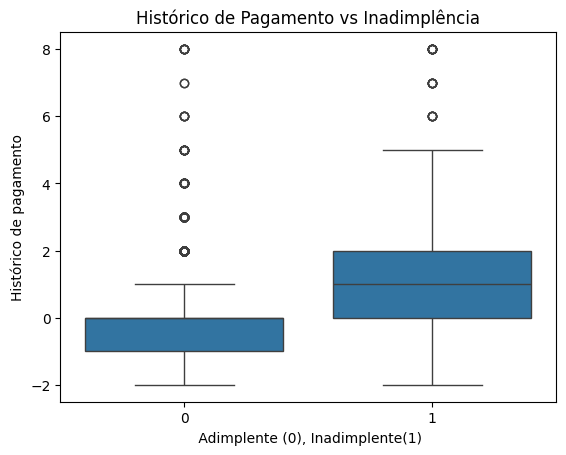

In [15]:
sns.boxplot(x='default.payment.next.month', y='PAY_0', data=df)
plt.title("Histórico de Pagamento vs Inadimplência")
plt.xlabel(" Adimplente (0), Inadimplente(1)")
plt.ylabel("Histórico de pagamento")
plt.show()

O grupo inadimplente apresenta maior histórico de atrasos nos pagamentos, sugerindo que esse é um dos fatores mais relevantes para prever inadimplência.

### Relação entre a dívida total e a inadimplência

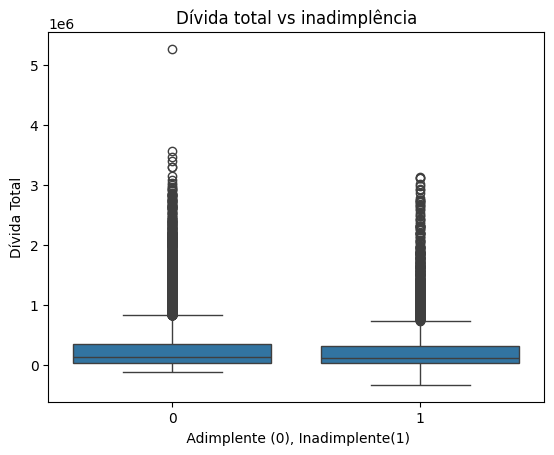

In [16]:
sns.boxplot(x='default.payment.next.month', y="divida_total", data=df)
plt.title("Dívida total vs inadimplência")
plt.xlabel(" Adimplente (0), Inadimplente(1)")
plt.ylabel("Dívida Total")
plt.show()

Observa-se que clientes inadimplentes apresentam volume maior de dívida acumulada, reforçando que a responsabilidade financeira está relacionada ao risco de inadimplência.

### Correlação entre os fatores analisados

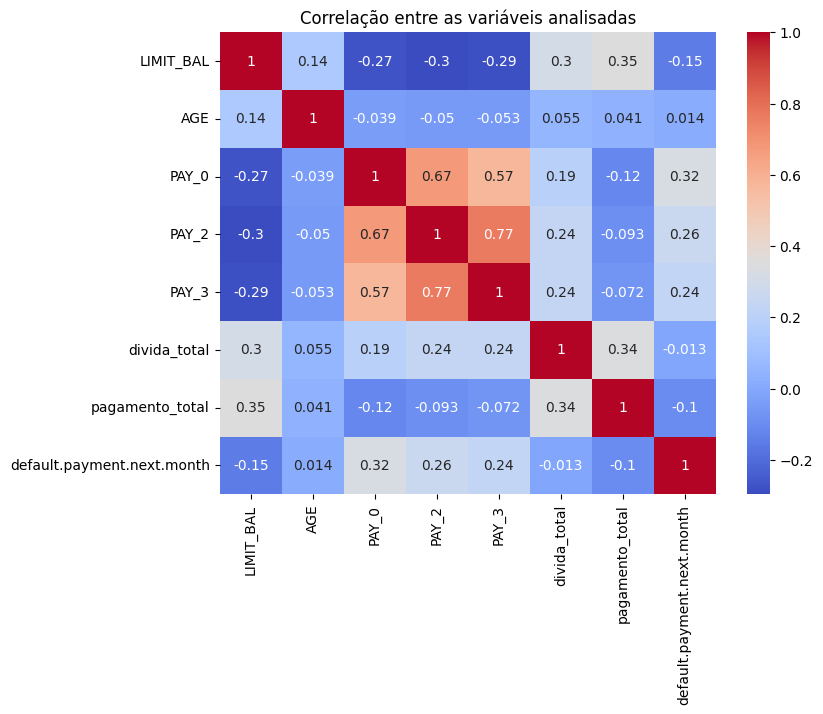

In [17]:
relacao = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'divida_total', 'pagamento_total','default.payment.next.month']
corr = df[relacao].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlação entre as variáveis analisadas")
plt.show()

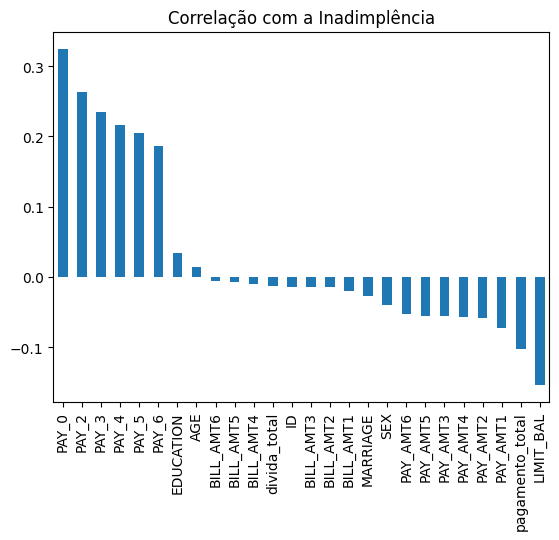

In [18]:
corr_target = df.corr()['default.payment.next.month'].sort_values(ascending=False)
corr_target.drop('default.payment.next.month').plot(kind='bar')
plt.title("Correlação com a Inadimplência")
plt.show()


Observa-se que variáveis relacionadas ao histórico de pagamento apresentam maior correlação com a inadimplência, indicando que atrasos anteriores são fortes indicadores de risco.
Variáveis como limite de crédito e idade apresentam menor correlação isolada, sugerindo que seu impacto pode ocorrer em conjunto com outros fatores.

## Testes Estatísticos

Nesta etapa, serão aplicados testes estatísticos simples para verificar se algumas diferenças observadas na análise exploratória são estatisticamente significativas.

Os testes ajudam a responder ao problema de pesquisa: quais características estão associadas à inadimplência?

In [19]:
media_limite_adimplentes = df[df['default.payment.next.month'] == 0]['LIMIT_BAL'].mean()
media_limite_inadimplentes = df[df['default.payment.next.month'] == 1]['LIMIT_BAL'].mean()

print("Média do limite de crédito - Adimplentes:", media_limite_adimplentes)
print("Média do limite de crédito - Inadimplentes:", media_limite_inadimplentes)

Média do limite de crédito - Adimplentes: 178099.72607430234
Média do limite de crédito - Inadimplentes: 130109.65641952984


In [20]:
from scipy.stats import ttest_ind

inadimplentes = df[df['default.payment.next.month'] == 1]['LIMIT_BAL']
adimplentes = df[df['default.payment.next.month'] == 0]['LIMIT_BAL']

t_stat, p_value = ttest_ind(inadimplentes, adimplentes)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -26.908521684796522
P-value: 1.3022439532597397e-157


### Interpretação do Teste t — Limite de Crédito

O teste t foi utilizado para verificar se existe diferença significativa entre o limite de crédito médio dos clientes adimplentes e inadimplentes.

- H0: não existe diferença significativa entre os limites médios dos dois grupos.
- H1: existe diferença significativa entre os limites médios dos dois grupos.

Como o p-value foi menor que 0,05, rejeitamos a hipótese nula. Isso indica que existe diferença estatisticamente significativa entre os grupos.

Na prática, esse resultado sugere que o limite de crédito pode estar associado ao risco de inadimplência. Esse insight é relevante porque mostra que características financeiras do cliente podem ajudar a prever o risco de não pagamento.

## Teste A/B — Histórico de Atraso no Pagamento

Neste teste, os clientes foram divididos em dois grupos:

- Grupo A: clientes sem atraso recente no pagamento.
- Grupo B: clientes com atraso recente no pagamento.

O objetivo é verificar se clientes com atraso anterior apresentam maior taxa de inadimplência no mês seguinte.

In [21]:
grupo_A = df[df['PAY_0'] <= 0]['default.payment.next.month']
grupo_B = df[df['PAY_0'] >= 1]['default.payment.next.month']

taxa_A = grupo_A.mean()
taxa_B = grupo_B.mean()

print("Taxa de inadimplência - Grupo A (sem atraso):", taxa_A)
print("Taxa de inadimplência - Grupo B (com atraso):", taxa_B)

t_stat_ab, p_value_ab = stats.ttest_ind(grupo_A, grupo_B, equal_var=False)

print("T-statistic:", t_stat_ab)
print("P-value:", p_value_ab)

Taxa de inadimplência - Grupo A (sem atraso): 0.13834009145026313
Taxa de inadimplência - Grupo B (com atraso): 0.5029334115576415
T-statistic: -56.38296096964179
P-value: 0.0


### Interpretação do Teste A/B

- H0: não existe diferença significativa na taxa de inadimplência entre clientes sem atraso e clientes com atraso.
- H1: existe diferença significativa na taxa de inadimplência entre os dois grupos.

O p-value obtido foi 0.0, ou seja, menor que 0,05. Portanto, rejeitamos a hipótese nula.

Além disso, a taxa de inadimplência do Grupo A, composto por clientes sem atraso recente, foi de aproximadamente 13,83%. Já no Grupo B, composto por clientes com atraso recente, a taxa foi de aproximadamente 50,29%.

Esse resultado mostra que clientes com atraso recente apresentam uma taxa de inadimplência muito maior no mês seguinte. Assim, o histórico de atraso no pagamento se apresenta como um dos principais indicadores de risco no projeto.

Esse é um insight importante para a sociedade impactada, pois instituições financeiras e pequenos negócios podem usar esse tipo de informação para apoiar decisões de crédito mais responsáveis, evitando tanto prejuízos quanto concessões inadequadas de crédito.

## Teste t Pareado — Valor da Fatura x Valor Pago

O teste t pareado foi utilizado para comparar duas informações do mesmo cliente: o valor da fatura e o valor efetivamente pago.

Neste caso, será analisado se existe diferença significativa entre o valor da fatura de setembro e o valor pago em setembro.

In [22]:
fatura_setembro = df['BILL_AMT1']
pagamento_setembro = df['PAY_AMT1']

media_fatura = fatura_setembro.mean()
media_pagamento = pagamento_setembro.mean()

print("Média da fatura em setembro:", media_fatura)
print("Média do pagamento em setembro:", media_pagamento)

t_stat_pareado, p_value_pareado = stats.ttest_rel(fatura_setembro, pagamento_setembro)

print("T-statistic:", t_stat_pareado)
print("P-value:", p_value_pareado)

Média da fatura em setembro: 51223.3309
Média do pagamento em setembro: 5663.5805
T-statistic: 107.84162344108482
P-value: 0.0


### Interpretação do Teste t Pareado

- H0: não existe diferença significativa entre o valor médio da fatura e o valor médio pago.
- H1: existe diferença significativa entre o valor médio da fatura e o valor médio pago.

O p-value obtido foi 0.0, ou seja, menor que 0,05. Portanto, rejeitamos a hipótese nula.

A média da fatura em setembro foi de aproximadamente 51.223, enquanto a média do pagamento foi de aproximadamente 5.664. Isso mostra uma diferença muito grande entre o valor cobrado e o valor efetivamente pago pelos clientes.

Esse resultado indica que muitos clientes pagam apenas uma parte da fatura, o que pode representar maior comprometimento financeiro e possível risco de inadimplência.

Esse insight é importante para o projeto porque mostra que, além do histórico de atraso, o comportamento de pagamento também pode ajudar a identificar clientes com maior risco.

## Simulação de Dados

A simulação foi utilizada para reforçar o entendimento dos testes estatísticos e do p-value.

Nesta simulação, criamos dois grupos fictícios para observar como o teste t se comporta quando existe diferença entre médias.

In [23]:
np.random.seed(42)

grupo_simulado_A = np.random.normal(loc=1000, scale=200, size=100)
grupo_simulado_B = np.random.normal(loc=1200, scale=200, size=100)

t_stat_sim, p_value_sim = stats.ttest_ind(grupo_simulado_A, grupo_simulado_B)

print("Média Grupo A:", grupo_simulado_A.mean())
print("Média Grupo B:", grupo_simulado_B.mean())
print("T-statistic:", t_stat_sim)
print("P-value:", p_value_sim)

Média Grupo A: 979.2306965211811
Média Grupo B: 1204.4609174099849
T-statistic: -8.551459943248739
P-value: 3.2929614287035575e-15


### Interpretação da Simulação

Na simulação, o Grupo A apresentou média aproximada de 979,23, enquanto o Grupo B apresentou média aproximada de 1.204,46.

O p-value obtido foi aproximadamente 3.29e-15, ou seja, muito menor que 0,05. Portanto, rejeitamos a hipótese nula, indicando que existe diferença estatisticamente significativa entre os dois grupos simulados.

Essa simulação ajuda a entender o funcionamento dos testes estatísticos: quando existe uma diferença clara entre as médias dos grupos, o teste tende a gerar um p-value baixo.

A simulação foi incluída para reforçar o entendimento do conceito de p-value e apoiar a interpretação dos testes aplicados ao dataset real.

## Protótipo da Solução Analítica

Nesta fase, o protótipo consiste em um pipeline inicial de análise preditiva, composto pelas seguintes etapas:

1. carregamento e compreensão dos dados;
2. tratamento de inconsistências;
3. criação de variáveis derivadas;
4. análise exploratória;
5. aplicação de teste estatístico;
6. treinamento inicial de modelos de classificação;
7. avaliação preliminar dos resultados.

Esse protótipo tem como objetivo demonstrar a viabilidade da solução proposta para identificar clientes com maior risco de inadimplência.

## Modelagem Preditiva 

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [25]:
# Separação entre variáveis explicativas e variável alvo
X = df.drop(columns=['ID', 'default.payment.next.month'])
y = df['default.payment.next.month']

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Padronização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 1. Regressão Logística

Para problemas de classificação (sim ou não).

In [26]:
modelo_logistico = LogisticRegression(max_iter=10000, random_state=42)
modelo_logistico.fit(X_train_scaled, y_train)

y_pred_log = modelo_logistico.predict(X_test_scaled)

print("Regressão Logística")
print("Acurácia:", accuracy_score(y_test, y_pred_log))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_log))
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_log))

Regressão Logística
Acurácia: 0.8077777777777778
Matriz de Confusão:
[[6800  209]
 [1521  470]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      7009
           1       0.69      0.24      0.35      1991

    accuracy                           0.81      9000
   macro avg       0.75      0.60      0.62      9000
weighted avg       0.79      0.81      0.77      9000



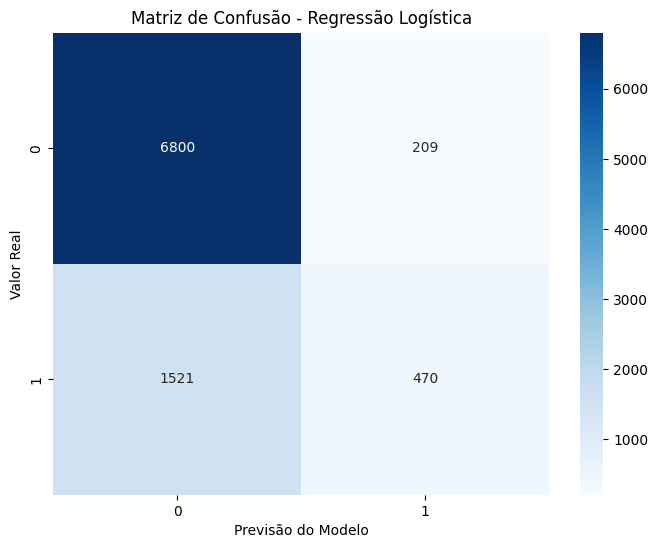

In [27]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.show()

Apesar da acurácia geral ser satisfatória, o modelo apresentou baixo recall para a classe inadimplente. Isso indica que muitos clientes inadimplentes não foram identificados corretamente pelo modelo.

Esse resultado é importante, pois o objetivo do projeto não é apenas acertar a maioria dos casos, mas principalmente identificar clientes com risco de inadimplência.

Nas próximas etapas, será necessário comparar outros modelos e possivelmente aplicar técnicas para lidar com o desbalanceamento da base.

### 2. Árvore de Decisão


In [28]:
modelo_arvore = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_arvore.fit(X_train, y_train)

y_pred_arvore = modelo_arvore.predict(X_test)

print("Árvore de Decisão")
print("Acurácia:", accuracy_score(y_test, y_pred_arvore))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_arvore))
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_arvore))

Árvore de Decisão
Acurácia: 0.8175555555555556
Matriz de Confusão:
[[6647  362]
 [1280  711]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      7009
           1       0.66      0.36      0.46      1991

    accuracy                           0.82      9000
   macro avg       0.75      0.65      0.68      9000
weighted avg       0.80      0.82      0.80      9000



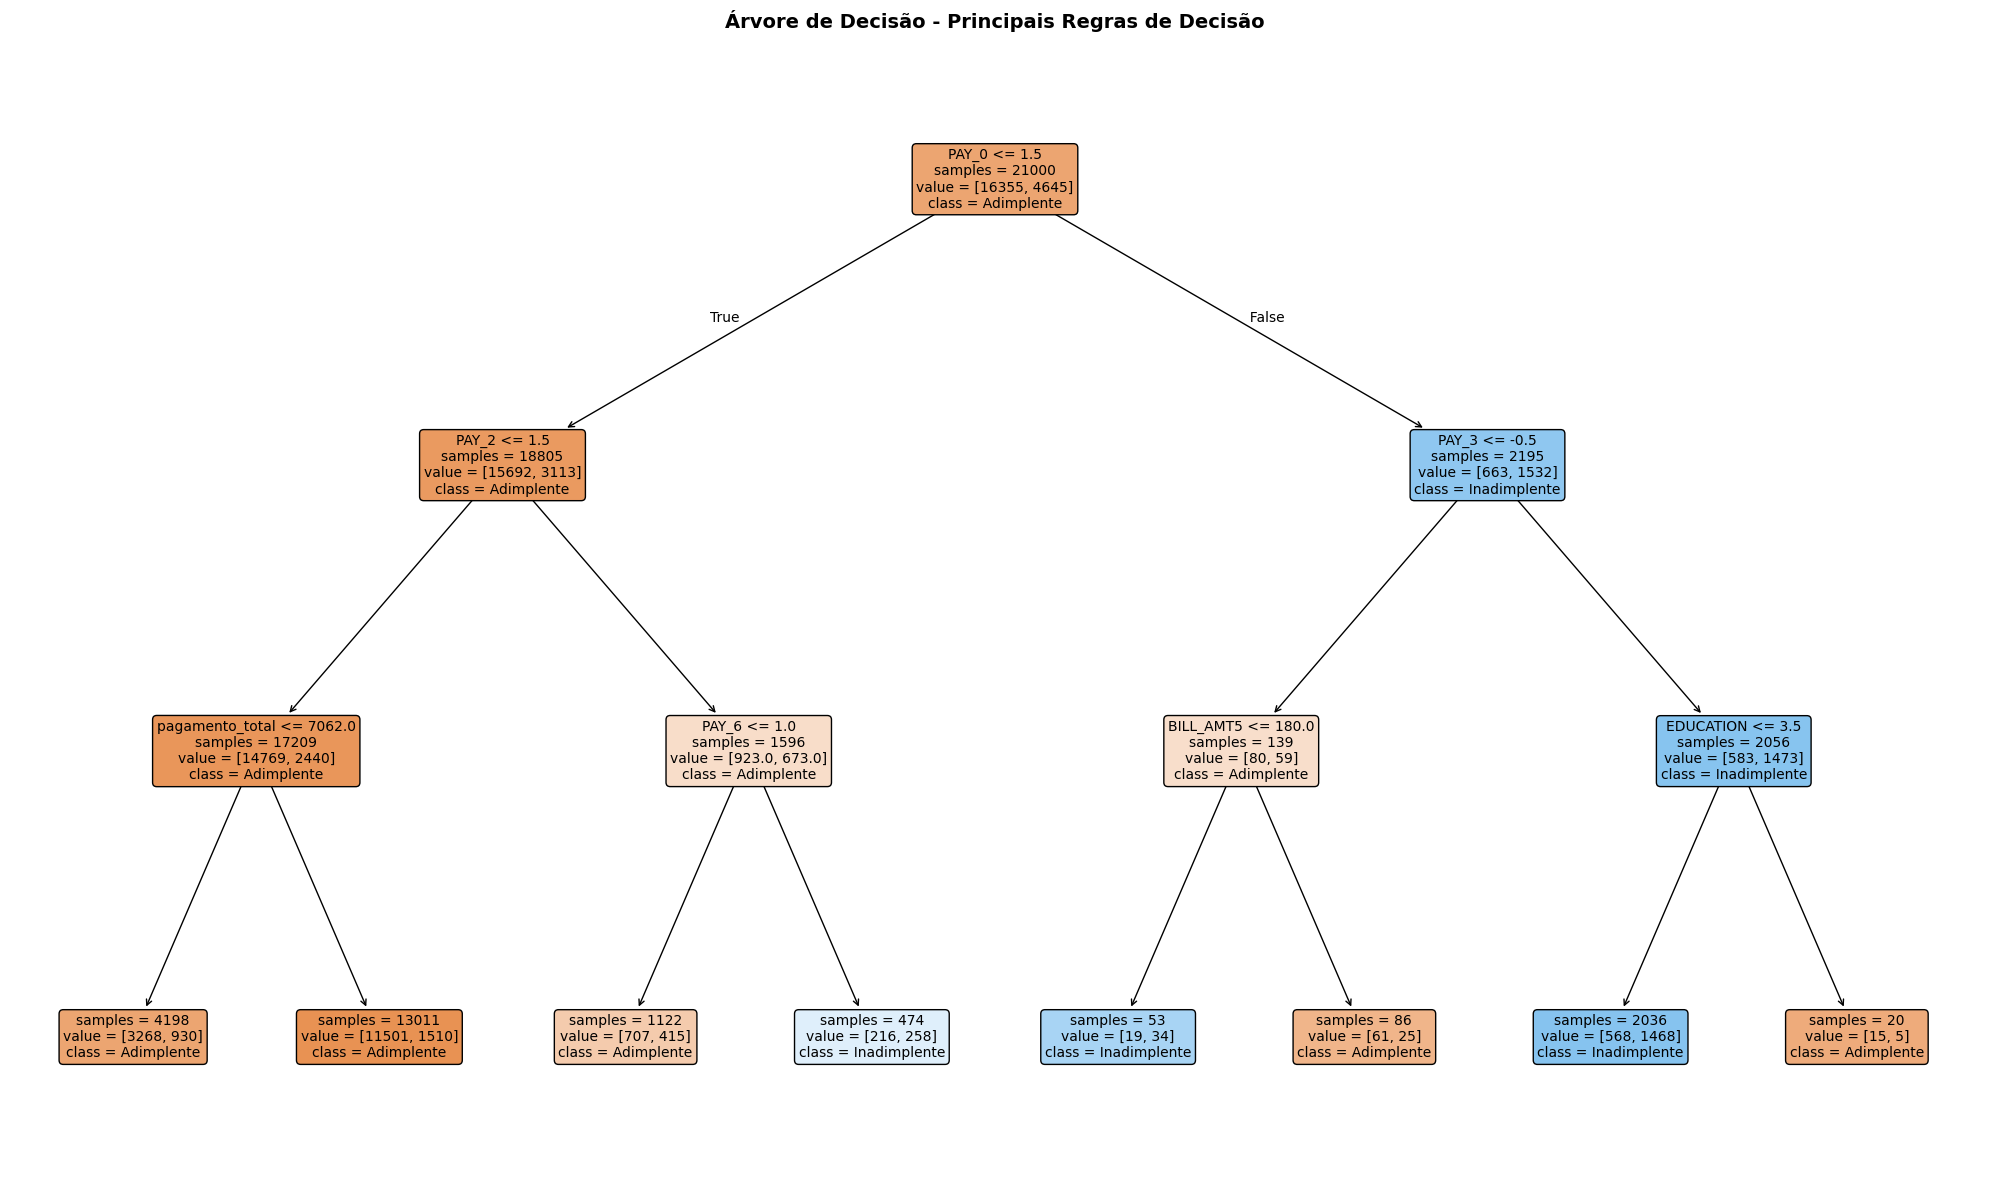

In [29]:
plt.figure(figsize=(20, 12))

plot_tree(
    modelo_arvore,
    feature_names=X.columns,
    class_names=['Adimplente', 'Inadimplente'],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=False,
    impurity=False
)

plt.title('Árvore de Decisão - Principais Regras de Decisão', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretação da Árvore de Decisão

A árvore de decisão permite visualizar as principais regras utilizadas pelo modelo para classificar clientes como adimplentes ou inadimplentes.

Observa-se que variáveis relacionadas ao histórico de pagamento aparecem entre os principais critérios de decisão, reforçando os resultados obtidos na análise exploratória e na matriz de correlação.

A profundidade da árvore foi limitada para facilitar a visualização e evitar um modelo excessivamente complexo.

### 3. Random Forest

In [30]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

print("Random Forest")
print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_rf))

Random Forest
Acurácia: 0.8163333333333334
Matriz de Confusão:
[[6664  345]
 [1308  683]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      7009
           1       0.66      0.34      0.45      1991

    accuracy                           0.82      9000
   macro avg       0.75      0.65      0.67      9000
weighted avg       0.80      0.82      0.79      9000



## Comparação dos modelos

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score

metricas_modelos = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Árvore de Decisão', 'Random Forest'],
    'Acurácia': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_arvore),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precisão Inadimplentes': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_arvore),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall Inadimplentes': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_arvore),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-score Inadimplentes': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_arvore),
        f1_score(y_test, y_pred_rf)
    ]
})

metricas_modelos

,Modelo,Acurácia,Precisão Inadimplentes,Recall Inadimplentes,F1-score Inadimplentes
0,Regressão Logística,0.807778,0.692194,0.236062,0.352060
1,Árvore de Decisão,0.817556,0.662628,0.357107,0.464099
2,Random Forest,0.816333,0.664397,0.343044,0.452468


## Interpretação da Comparação dos Modelos

A comparação entre os modelos permite avaliar qual algoritmo apresentou melhor desempenho inicial na previsão de inadimplência.

A acurácia mostra o percentual geral de acertos do modelo. Porém, no contexto de inadimplência, essa métrica sozinha não é suficiente. Também é importante observar métricas como recall e F1-score da classe inadimplente.

O recall da classe inadimplente indica quantos clientes inadimplentes foram identificados corretamente pelo modelo. Essa métrica é importante porque falsos negativos representam clientes de risco que foram classificados como seguros.

Os modelos apresentaram acurácias próximas, em torno de 81%. A Árvore de Decisão apresentou leve vantagem em acurácia e também melhor desempenho na identificação da classe inadimplente em relação aos demais modelos.

Mesmo assim, os resultados mostram que ainda há espaço para melhorar a identificação dos clientes inadimplentes, principalmente em etapas futuras do projeto.

## Insights Iniciais Gerados

A partir da análise preliminar dos dados, testes estatísticos e modelos aplicados, foram identificados alguns insights importantes:

1. O histórico de pagamento é um dos principais fatores associados à inadimplência. Clientes com atrasos anteriores apresentam maior chance de inadimplência no mês seguinte.

2. O limite de crédito apresenta diferença significativa entre clientes adimplentes e inadimplentes, indicando que essa variável pode contribuir para a análise de risco.

3. A comparação entre valor da fatura e valor pago mostra que o comportamento de pagamento do cliente é relevante para entender sua situação financeira.

4. Os modelos de machine learning apresentaram desempenho inicial satisfatório em acurácia, com resultados próximos de 81%. Porém, o recall da classe inadimplente ainda foi baixo, indicando dificuldade em identificar todos os clientes com risco de inadimplência.

5. Para a sociedade impactada, especialmente instituições financeiras, pequenos negócios e consumidores, os resultados mostram que modelos preditivos podem apoiar decisões de crédito mais responsáveis.

6. O modelo não deve ser usado como decisão única e automática, mas como ferramenta de apoio à análise, pois decisões de crédito precisam considerar aspectos éticos e possíveis vieses.

## Conclusão da Entrega 2

Nesta etapa, foi desenvolvido um protótipo inicial de solução analítica para previsão de inadimplência em clientes de cartão de crédito.

Foram realizadas etapas de tratamento dos dados, correção de inconsistências, criação de variáveis derivadas, análise exploratória, testes estatísticos e modelagem preditiva inicial.

Os testes estatísticos ajudaram a validar algumas hipóteses do projeto. O teste t indicou diferença significativa entre o limite de crédito de clientes adimplentes e inadimplentes. O teste A/B mostrou a importância do histórico de atraso no pagamento. Já o teste t pareado permitiu comparar o valor da fatura com o valor pago pelo cliente.

Na modelagem preditiva, foram aplicados três modelos de classificação: Regressão Logística, Árvore de Decisão e Random Forest.Os modelos apresentaram acurácias próximas, com leve vantagem para a Árvore de Decisão. No entanto, o recall da classe inadimplente ainda precisa ser melhorado, pois o objetivo do projeto é identificar clientes com maior risco de não pagamento.

Como próximos passos, serão feitos ajustes nos modelos, análise de importância das variáveis e possíveis melhorias para aumentar a capacidade de identificar clientes com maior risco de inadimplência.

# MVP e Refinamento da Solução

Nesta etapa final, o objetivo é **evoluir o protótipo  para um MVP final** :

- refinar a modelagem preditiva;
- comparar os resultados com métricas mais adequadas ao problema;
- analisar a importância das variáveis;
- incluir uma análise não supervisionada para segmentação de clientes;
- consolidar os principais insights e limitações do projeto.


## Refinamento da Modelagem Supervisionada

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

modelo_rf_final = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

modelo_rf_final.fit(X_train, y_train)
y_pred_rf_final = modelo_rf_final.predict(X_test)

print("Random Forest Refinado")
print("Acurácia:", accuracy_score(y_test, y_pred_rf_final))
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf_final))
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_rf_final))

Random Forest Refinado
Acurácia: 0.7875555555555556
Matriz de Confusão:
[[5968 1041]
 [ 871 1120]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      7009
           1       0.52      0.56      0.54      1991

    accuracy                           0.79      9000
   macro avg       0.70      0.71      0.70      9000
weighted avg       0.79      0.79      0.79      9000



O modelo Random Forest foi refinado com o objetivo de melhorar a identificação dos clientes inadimplentes, que são a classe mais importante para o problema do projeto.

Na versão refinada, foi utilizado o parâmetro **class_weight='balanced'**, que faz o modelo considerar o desbalanceamento entre clientes adimplentes e inadimplentes durante o treinamento. Isso é importante porque, na base de dados, existem mais clientes adimplentes do que inadimplentes.

O resultado mostrou uma acurácia de aproximadamente 78,76%, um pouco menor que a dos modelos anteriores. Porém, o recall da classe inadimplente aumentou para aproximadamente 56%.

Isso significa que o modelo passou a identificar corretamente uma quantidade maior de clientes com risco de inadimplência. Em contrapartida, houve uma redução na acurácia geral, pois o modelo passou a classificar mais clientes como possíveis inadimplentes.

Para este projeto, essa troca faz sentido, pois o objetivo principal não é apenas acertar a maioria dos casos, mas principalmente reduzir o número de clientes inadimplentes classificados incorretamente como seguros.

Assim, o modelo refinado apresentou um resultado mais adequado ao problema de risco de crédito, mesmo com uma pequena perda de desempenho geral.

## Comparação dos Modelos

A seguir, comparamos os modelos já treinados no protótipo com o modelo melhorado.

Além da acurácia, serão avaliados precisão, recall e F1-score para a classe inadimplente.

In [33]:
metricas_finais = pd.DataFrame({
    'Modelo': [
        'Regressão Logística',
        'Árvore de Decisão',
        'Random Forest',
        'Random Forest Refinado'
    ],
    'Acurácia': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_arvore),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_final)
    ],
    'Precisão Inadimplentes': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_arvore),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_final)
    ],
    'Recall Inadimplentes': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_arvore),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_final)
    ],
    'F1-score Inadimplentes': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_arvore),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_final)
    ]
})

metricas_finais

,Modelo,Acurácia,Precisão Inadimplentes,Recall Inadimplentes,F1-score Inadimplentes
0,Regressão Logística,0.807778,0.692194,0.236062,0.352060
1,Árvore de Decisão,0.817556,0.662628,0.357107,0.464099
2,Random Forest,0.816333,0.664397,0.343044,0.452468
3,Random Forest Refinado,0.787556,0.518279,0.562531,0.539499


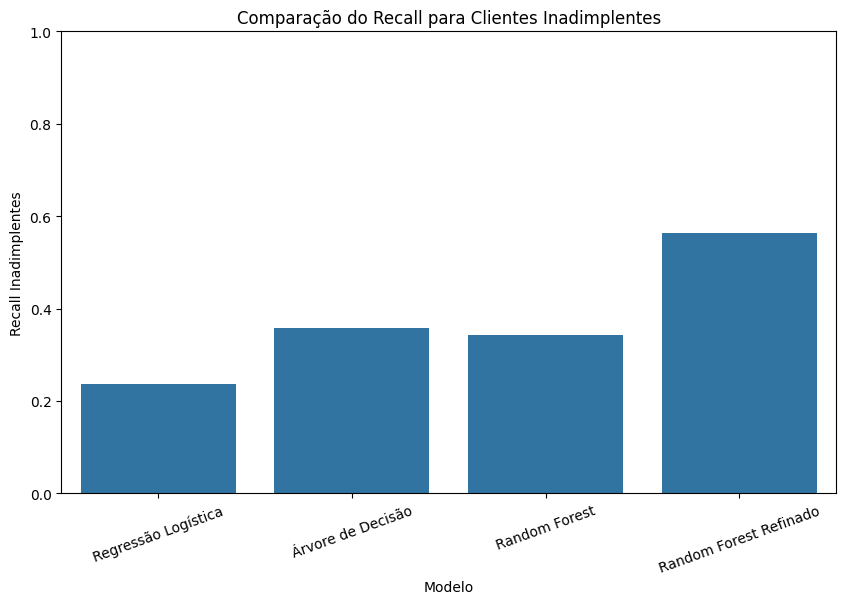

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='Recall Inadimplentes', data=metricas_finais)
plt.title('Comparação do Recall para Clientes Inadimplentes')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

### Comparação entre os Modelos

A comparação final mostra que os modelos apresentaram comportamentos diferentes em relação à acurácia e à identificação dos clientes inadimplentes.

A Regressão Logística apresentou acurácia de aproximadamente 80,78%, porém teve o menor recall para inadimplentes, cerca de 23,60%. Isso significa que, apesar de acertar boa parte dos casos gerais, ela deixou de identificar muitos clientes com risco de inadimplência.

A Árvore de Decisão e o Random Forest apresentaram acurácias um pouco maiores, próximas de 81%, e melhoraram o recall da classe inadimplente em relação à Regressão Logística. Mesmo assim, ainda não conseguiram identificar a maioria dos clientes inadimplentes.

O Random Forest Refinado apresentou a menor acurácia geral, aproximadamente 78,76%, mas obteve o melhor recall para inadimplentes, cerca de 56,25%. Isso indica que ele conseguiu identificar uma quantidade maior de clientes com risco de não pagamento.

Para este projeto, o recall da classe inadimplente é uma métrica muito importante, pois falsos negativos representam clientes inadimplentes classificados como seguros. Por isso, mesmo com uma acurácia um pouco menor, o Random Forest Refinado se mostrou mais adequado ao objetivo do projeto.

## Importância das Variáveis

Para tornar o modelo mais interpretável, analisamos quais variáveis tiveram maior importância para o Random Forest refinado.

Essa etapa ajuda a responder ao problema de pesquisa, pois mostra quais características mais contribuíram para a previsão de inadimplência.

In [35]:
importancias = pd.DataFrame({
    'Variável': X.columns,
    'Importância': modelo_rf_final.feature_importances_
}).sort_values(by='Importância', ascending=False)

importancias.head(10)

,Variável,Importância
5,PAY_0,0.232817
6,PAY_2,0.118749
7,PAY_3,0.062752
24,pagamento_total,0.048749
8,PAY_4,0.044996
9,PAY_5,0.043773
0,LIMIT_BAL,0.041729
11,BILL_AMT1,0.033231
18,PAY_AMT2,0.032475
10,PAY_6,0.032171


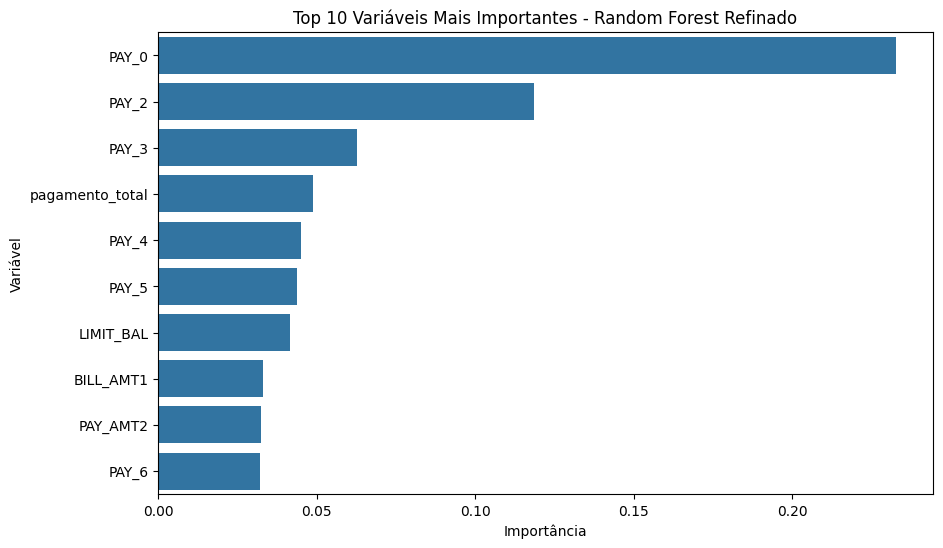

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=importancias.head(10))
plt.title('Top 10 Variáveis Mais Importantes - Random Forest Refinado')
plt.show()

A análise de importância das variáveis mostra quais atributos tiveram maior influência nas decisões do modelo Random Forest Refinado.

A variável mais importante foi **PAY_0**, que representa o histórico de pagamento mais recente. Isso indica que o comportamento de pagamento do cliente no mês mais próximo da previsão tem forte relação com o risco de inadimplência.

Em seguida aparecem **PAY_2** e **PAY_3**, que também representam o histórico de pagamento dos meses anteriores. Esse resultado reforça um dos principais insights do projeto: atrasos anteriores são fortes indicadores de inadimplência futura.

A variável **pagamento_total** também aparece entre as mais importantes, mostrando que o valor total pago pelo cliente nos meses analisados contribui para entender seu comportamento financeiro.

Além disso, variáveis como **LIMIT_BAL**, **BILL_AMT1** e **PAY_AMT2** aparecem na lista, indicando que o limite de crédito, o valor da fatura e os pagamentos anteriores também ajudam o modelo a identificar perfis de risco.

De forma geral, a análise confirma que o histórico de pagamento é o principal fator associado à inadimplência no modelo. Isso está alinhado com os testes estatísticos e com a análise exploratória realizados anteriormente.

# Modelo Não Supervisionado - Segmentação de Clientes

Além dos modelos supervisionados, também foi aplicada uma técnica de aprendizado não supervisionado.

Diferente dos modelos anteriores, o modelo não supervisionado não usa a variável alvo para aprender. O objetivo aqui é **segmentar clientes com características semelhantes**, formando grupos de comportamento.

Para isso, será utilizado o algoritmo **K-Means**, que agrupa os clientes com base em variáveis financeiras e comportamentais.

In [37]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

variaveis_cluster = [
    'LIMIT_BAL', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'divida_total', 'pagamento_total'
]

dados_cluster = df[variaveis_cluster].copy()

scaler_cluster = StandardScaler()
dados_cluster_scaled = scaler_cluster.fit_transform(dados_cluster)

## Escolha simples do número de grupos

Para manter a análise objetiva, testamos alguns valores de `k` e observamos o silhouette score.

O silhouette score ajuda a avaliar se os grupos formados estão relativamente bem separados. Valores maiores indicam melhor separação entre os grupos.

In [40]:
silhouettes = []
ks = range(2, 6)

for k in ks:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(dados_cluster_scaled)
    
    score = silhouette_score(
        dados_cluster_scaled, 
        labels_temp, 
        sample_size=3000, 
        random_state=42
    )
    
    silhouettes.append(score)

resultado_silhouette = pd.DataFrame({
    'Numero de grupos (k)': list(ks),
    'Silhouette Score': silhouettes
})

resultado_silhouette

,Numero de grupos (k),Silhouette Score
0,2,0.270304
1,3,0.264608
2,4,0.259755
3,5,0.214473


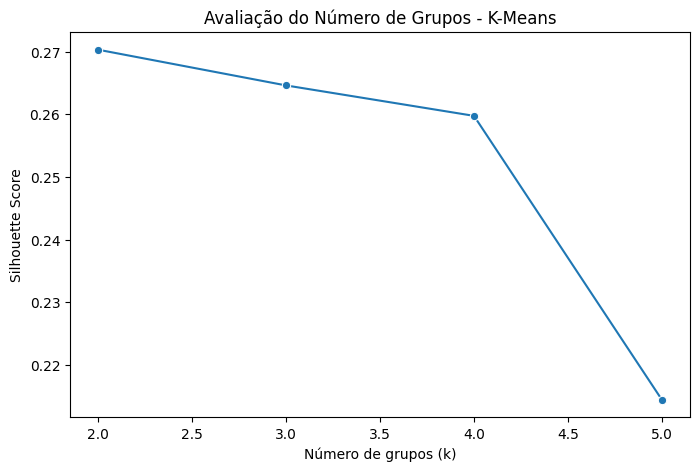

In [43]:
plt.figure(figsize=(8, 5))
sns.lineplot(
    x='Numero de grupos (k)', 
    y='Silhouette Score', 
    data=resultado_silhouette, 
    marker='o'
)

plt.title('Avaliação do Número de Grupos - K-Means')
plt.xlabel('Número de grupos (k)')
plt.ylabel('Silhouette Score')
plt.show()

## Aplicação do K-Means

Para facilitar a interpretação no MVP final, utilizaremos `k = 3`, separando os clientes em três grupos de perfil.

Após criar os grupos, analisamos a taxa de inadimplência de cada cluster. Importante: a variável de inadimplência **não é usada para criar os grupos**, apenas para interpretar o perfil de cada grupo depois.

In [44]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_cliente'] = kmeans.fit_predict(dados_cluster_scaled)

df[['cluster_cliente']].head()

,cluster_cliente
0,2
1,2
2,2
3,2
4,2


In [45]:
perfil_clusters = df.groupby('cluster_cliente').agg(
    qtd_clientes=('ID', 'count'),
    idade_media=('AGE', 'mean'),
    limite_medio=('LIMIT_BAL', 'mean'),
    atraso_setembro_medio=('PAY_0', 'mean'),
    divida_media=('divida_total', 'mean'),
    pagamento_medio=('pagamento_total', 'mean'),
    taxa_inadimplencia=('default.payment.next.month', 'mean')
).reset_index()

perfil_clusters

,cluster_cliente,qtd_clientes,idade_media,limite_medio,atraso_setembro_medio,divida_media,pagamento_medio,taxa_inadimplencia
0,0,3440,35.024709,86625.000000,1.604360,294834.291860,14106.390116,0.614535
1,1,9300,36.751183,223619.354839,-0.822366,42601.140753,31059.792581,0.163333
2,2,17260,34.895365,153353.399768,0.094322,387336.591136,35466.959676,0.173986


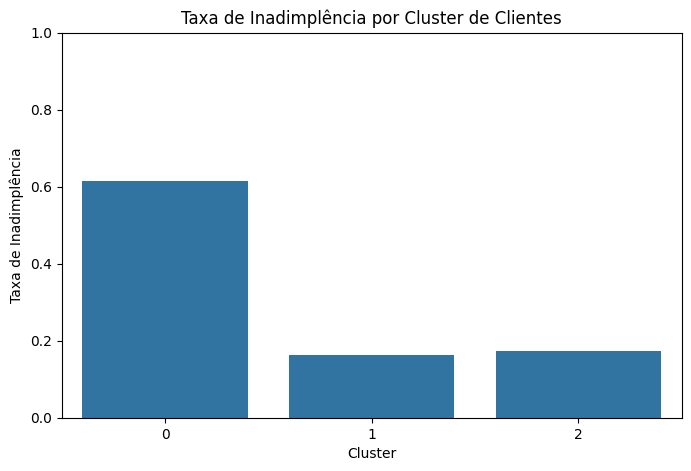

In [46]:
plt.figure(figsize=(8, 5))
sns.barplot(x='cluster_cliente', y='taxa_inadimplencia', data=perfil_clusters)
plt.title('Taxa de Inadimplência por Cluster de Clientes')
plt.xlabel('Cluster')
plt.ylabel('Taxa de Inadimplência')
plt.ylim(0, 1)
plt.show()

### Modelagem Não Supervisionada

Diferente dos modelos supervisionados, como Regressão Logística, Árvore de Decisão e Random Forest, o K-Means não utiliza a variável alvo para aprender. Ele agrupa os clientes com base nas características disponíveis, como limite de crédito, histórico de pagamento, dívida total e pagamento total.

Para escolher a quantidade de grupos, foi analisado o Silhouette Score para diferentes valores de **k**. O melhor resultado apareceu com **k = 2**, porém a diferença para **k = 3** foi pequena. Optamos por utilizar 3 grupos porque essa quantidade permite uma interpretação mais útil dos perfis de clientes, separando-os em diferentes níveis de risco.

Após a aplicação do K-Means, os clientes foram divididos em três clusters:

- Cluster 0: grupo com maior taxa de inadimplência, aproximadamente 61,44%;
- Cluster 1: grupo com menor taxa de inadimplência, aproximadamente 16,33%;
- Cluster 2: grupo com taxa de inadimplência próxima de 17,40%.

O Cluster 0 se destaca como o grupo de maior risco. Ele apresenta menor limite médio de crédito e maior média de atraso recente no pagamento. Isso indica que clientes com histórico de atraso e menor limite tendem a apresentar maior risco de inadimplência.

Os Clusters 1 e 2 apresentam taxas de inadimplência bem menores. Apesar de possuírem perfis financeiros diferentes, ambos representam grupos com menor risco em comparação ao Cluster 0.

Essa análise complementa os modelos supervisionados, pois além de prever se um cliente pode ser inadimplente, também ajuda a entender perfis de clientes.

# Demonstração do MVP Final

Nesta etapa, criamos uma função simples para simular o uso do modelo em um cliente.

A função recebe os dados de um cliente, calcula a probabilidade de inadimplência e retorna uma classificação de risco.

Essa função representa a ideia central do MVP: transformar dados financeiros em uma indicação inicial de risco.

In [47]:
def classificar_risco_cliente(dados_cliente, modelo=modelo_rf_final):
    probabilidade = modelo.predict_proba(dados_cliente)[0][1]
    classificacao = 'Alto risco de inadimplência' if probabilidade >= 0.5 else 'Baixo risco de inadimplência'
    return probabilidade, classificacao

# Exemplo de uso com um cliente da base de teste
cliente_exemplo = X_test.iloc[[0]]
probabilidade, classificacao = classificar_risco_cliente(cliente_exemplo)

print('Probabilidade estimada de inadimplência:', probabilidade)
print('Classificação:', classificacao)

Probabilidade estimada de inadimplência: 0.22373962010961287
Classificação: Baixo risco de inadimplência


### Interpretação da Demonstração do MVP

A função acima demonstra como o modelo poderia ser usado em um protótipo real.

Ao receber os dados de um cliente, o modelo retorna uma probabilidade de inadimplência e uma classificação simples de risco.

Essa saída pode apoiar uma tomada de decisão, mas não deve ser utilizada como decisão automática e definitiva. Em aplicações reais, seria necessário considerar critérios éticos, transparência, revisão humana e possíveis vieses nos dados.

No exemplo apresentado, o cliente analisado obteve uma probabilidade estimada de inadimplência de aproximadamente 22,74%, sendo classificado como **baixo risco de inadimplência**.


# Insights Finais do Projeto

Com base na análise completa realizada ao longo das três fases do projeto, foi possível identificar os seguintes insights:

1. **O histórico de pagamento é o principal indicador de risco.**  
   Variáveis como **PAY_0**, **PAY_2** e **PAY_3** apareceram como as mais importantes no modelo, indicando que atrasos anteriores são fortes sinais de possível inadimplência futura.

2. **Clientes com atraso recente apresentam risco muito maior.**  
   No Teste A/B, clientes sem atraso recente tiveram taxa de inadimplência de aproximadamente 13,83%, enquanto clientes com atraso recente apresentaram taxa próxima de 50,29%. Esse foi um dos insights mais relevantes do projeto.

3. **O limite de crédito possui relação com a inadimplência.**  
   O teste estatístico mostrou diferença significativa entre o limite médio de clientes adimplentes e inadimplentes, indicando que essa variável pode contribuir para a análise de risco.

4. **O comportamento de pagamento ajuda a entender a situação financeira do cliente.**  
   A diferença entre o valor da fatura e o valor pago mostrou que muitos clientes pagam apenas parte do valor devido, o que pode indicar maior comprometimento financeiro.

5. **Acurácia sozinha não é suficiente para avaliar o modelo.**  
   Em problemas de risco de crédito, é importante analisar principalmente o recall da classe inadimplente, pois falsos negativos representam clientes de risco classificados como seguros.

6. **O modelo refinado foi mais adequado ao objetivo do projeto.**  
   O Random Forest Refinado reduziu um pouco a acurácia geral, mas aumentou o recall dos inadimplentes. Essa troca é aceitável porque o foco do projeto é identificar clientes com maior risco de não pagamento.

7. **A segmentação não supervisionada complementou a análise.**  
   O K-Means permitiu dividir os clientes em grupos com perfis semelhantes. Um dos clusters apresentou taxa de inadimplência muito superior aos demais, mostrando que a segmentação pode ajudar a identificar perfis de maior risco.

8. **O MVP demonstra a aplicação prática do projeto.**  
   A função criada recebe os dados de um cliente e retorna uma probabilidade estimada de inadimplência e uma classificação de risco, mostrando como a solução poderia funcionar em um cenário real.

9. **Impacto social e prático.**  
   A solução pode apoiar fintechs, instituições financeiras e pequenos negócios na tomada de decisões de crédito mais responsáveis, reduzindo riscos e evitando concessões inadequadas. Para os consumidores, pode contribuir para análises mais criteriosas e menos baseadas apenas em julgamento manual.

10. **O modelo deve ser usado como apoio, não como decisão automática.**  
   Apesar dos resultados positivos, uma solução desse tipo precisa considerar ética, transparência, revisão humana e possíveis vieses nos dados.

## Conclusão Final - MVP

Nesta fase final, o projeto foi consolidado como um MVP analítico para previsão de inadimplência em clientes de cartão de crédito.

A solução desenvolvida reuniu tratamento de dados, análise exploratória, testes estatísticos, modelos supervisionados, refinamento do modelo, análise de importância das variáveis e segmentação não supervisionada com K-Means.

Os resultados mostraram que o histórico de pagamento, o limite de crédito e o comportamento de pagamento são fatores relevantes para identificar risco de inadimplência.

O modelo refinado melhorou a identificação de clientes inadimplentes, mesmo com pequena redução na acurácia geral, tornando-se mais adequado ao objetivo do projeto.

Assim, o projeto atingiu seu objetivo ao demonstrar como a análise de dados e o aprendizado de máquina podem apoiar decisões de crédito mais responsáveis.